In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned/customer_churn_cleaned.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


In [7]:
print("Average Tenure:", df["tenure"].mean())
print("Average Monthly Charges:", df["MonthlyCharges"].mean())
print("Average Total Charges:", df["TotalCharges"].mean())

Average Tenure: 32.421786120591584
Average Monthly Charges: 64.79820819112628
Average Total Charges: 2283.300440841866


In [8]:
print("Median Tenure:", df["tenure"].median())
print("Median Monthly Charges:", df["MonthlyCharges"].median())
print("Median Total Charges:", df["TotalCharges"].median())

Median Tenure: 29.0
Median Monthly Charges: 70.35
Median Total Charges: 1397.475


In [9]:
print(df["tenure"].mode())
print(df["MonthlyCharges"].mode())

0    1
Name: tenure, dtype: int64
0    20.05
Name: MonthlyCharges, dtype: float64


In [10]:
print(df["MonthlyCharges"].var())
print(df["TotalCharges"].var())

905.1658245517284
5138252.40705357


In [11]:
print(df["MonthlyCharges"].std())
print(df["TotalCharges"].std())

30.08597388404983
2266.7713618831453


In [12]:
#Quartiles
df[["tenure","MonthlyCharges","TotalCharges"]].quantile([0.25,0.5,0.75])

,tenure,MonthlyCharges,TotalCharges
0.25,9.0,35.5875,401.4500
0.50,29.0,70.3500,1397.4750
0.75,55.0,89.8625,3794.7375


In [13]:
#Interquartile Range (IQR)
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

54.275


In [14]:
#Detect Outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["MonthlyCharges"] < lower) | (df["MonthlyCharges"] > upper)]

print(outliers.shape)

(0, 21)


In [15]:
#Correlation Matrix
corr = df[["tenure","MonthlyCharges","TotalCharges"]].corr()

corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


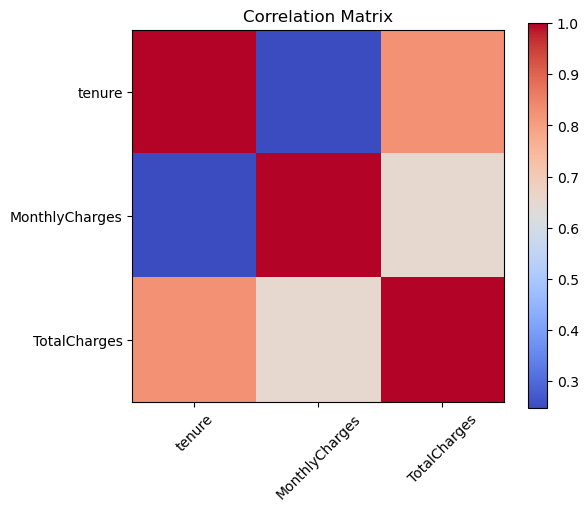

In [16]:
#Correlation Heatmap (using only Matplotlib)
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [17]:
#Churn Percentage
(df["Churn"].value_counts(normalize=True) * 100)

No     73.421502
Yes    26.578498
Name: Churn, dtype: float64

In [18]:
#Average Monthly Charges by Churn
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [19]:
#Average Tenure by Churn
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [20]:
#Hypothesis Testing (Independent t-test)
from scipy.stats import ttest_ind

In [21]:
churn_yes = df[df["Churn"]=="Yes"]["MonthlyCharges"]
churn_no = df[df["Churn"]=="No"]["MonthlyCharges"]

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 16.47959313114872
P Value: 6.760843117980302e-60


In [22]:
if p_value < 0.05:
    print("Reject the null hypothesis")
    print("Monthly charges differ significantly between churned and retained customers.")
else:
    print("Fail to reject the null hypothesis")
    print("No statistically significant difference found.")

Reject the null hypothesis
Monthly charges differ significantly between churned and retained customers.


In [23]:
#Save summery
summary = df.describe()

summary.to_csv("../reports/statistical_summary.csv")